# Module 6 / Class 2 - Optimizer Showdown

This notebook trains the same MNIST model with SGD, SGD with
momentum, and Adam. The architecture and data stay the same so the
optimizer comparison is fair.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import Markdown, display

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Load and Prepare MNIST

Pixel values are scaled to `0-1` so the optimizers work with small
input numbers.

In [2]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

x_train = x_train_full[:10000].astype("float32") / 255.0
y_train = y_train_full[:10000]
x_valid = x_train_full[10000:12000].astype("float32") / 255.0
y_valid = y_train_full[10000:12000]
x_test = x_test_full[:3000].astype("float32") / 255.0
y_test = y_test_full[:3000]

print("train:", x_train.shape, "valid:", x_valid.shape, "test:", x_test.shape)

train: (10000, 28, 28) valid: (2000, 28, 28) test: (3000, 28, 28)


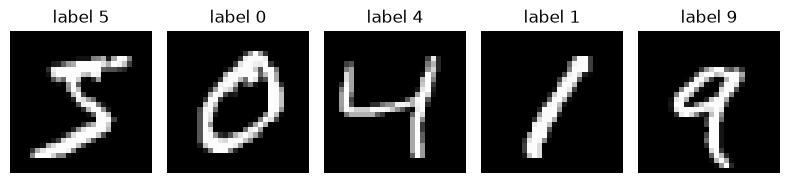

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(8, 2))
for ax, image, label in zip(axes, x_train[:5], y_train[:5]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"label {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Same Model, Different Optimizers

Each run uses a one-hidden-layer neural network. Only the optimizer
changes.

In [4]:
def build_mlp():
    return keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

optimizer_options = {
    "SGD": lambda: keras.optimizers.SGD(learning_rate=0.1),
    "SGD + momentum": lambda: keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
    "Adam": lambda: keras.optimizers.Adam(learning_rate=0.001),
}

EPOCHS = 6
histories = {}
results = []

for optimizer_name, make_optimizer in optimizer_options.items():
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = build_mlp()
    model.compile(
        optimizer=make_optimizer(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_valid, y_valid),
        epochs=EPOCHS,
        batch_size=128,
        verbose=0,
    )

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
    histories[optimizer_name] = history.history
    results.append({
        "optimizer": optimizer_name,
        "final_train_accuracy": history.history["accuracy"][-1],
        "final_valid_accuracy": history.history["val_accuracy"][-1],
        "test_accuracy": test_accuracy,
    })

results_df = pd.DataFrame(results).sort_values("test_accuracy", ascending=False)
results_df

,optimizer,final_train_accuracy,final_valid_accuracy,test_accuracy
1,SGD + momentum,0.9799,0.950,0.930667
2,Adam,0.9550,0.941,0.916000
0,SGD,0.9266,0.912,0.881000


In [5]:
def first_epoch_at_or_above(values, threshold=0.95):
    for epoch_number, value in enumerate(values, start=1):
        if value >= threshold:
            return epoch_number
    return None

convergence_rows = []
for optimizer_name, history in histories.items():
    convergence_rows.append({
        "optimizer": optimizer_name,
        "first_train_epoch_at_95_percent": first_epoch_at_or_above(history["accuracy"]),
        "first_valid_epoch_at_95_percent": first_epoch_at_or_above(history["val_accuracy"]),
    })

convergence_df = pd.DataFrame(convergence_rows)
convergence_df

,optimizer,first_train_epoch_at_95_percent,first_valid_epoch_at_95_percent
0,SGD,NaN,NaN
1,SGD + momentum,3.0,5.0
2,Adam,6.0,NaN


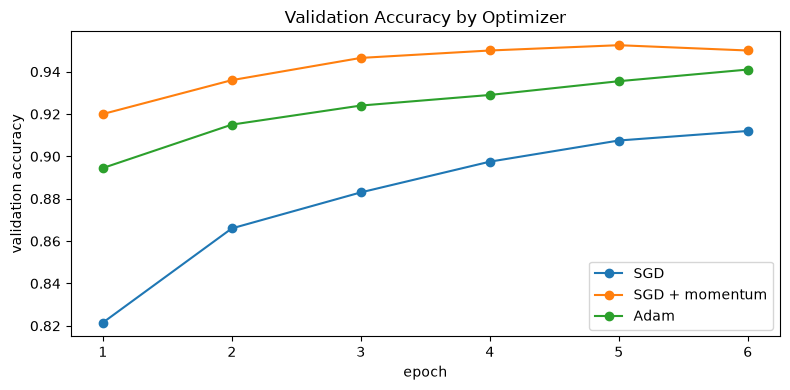

In [6]:
plt.figure(figsize=(8, 4))
for optimizer_name, history in histories.items():
    plt.plot(history["val_accuracy"], marker="o", label=optimizer_name)

plt.title("Validation Accuracy by Optimizer")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.xticks(range(EPOCHS), [str(i) for i in range(1, EPOCHS + 1)])
plt.legend()
plt.tight_layout()
plt.show()

## 3. Analysis Questions - Completed

The next cell answers the assignment questions using the results
from this run.

In [7]:
best_optimizer = results_df.iloc[0]["optimizer"]

reached_95 = convergence_df.dropna(subset=["first_train_epoch_at_95_percent"])
if len(reached_95) > 0:
    fastest_optimizer = reached_95.sort_values("first_train_epoch_at_95_percent").iloc[0]["optimizer"]
    fastest_text = f"{fastest_optimizer} reached 95% training accuracy first."
else:
    fastest_text = "None of the optimizers reached 95% training accuracy within this short run."

answer = f'''
1. **Highest final accuracy:** `{best_optimizer}` had the highest test accuracy in this run.
2. **Fastest convergence:** {fastest_text}
3. **Why Adam is popular:** Adam adapts the learning rate for each weight and usually needs less manual tuning than plain SGD.
4. **When plain SGD can be preferred:** Plain SGD can be useful when we want a simpler optimizer, strong control over the learning-rate schedule, or a model that may generalize better after careful tuning.
'''

display(Markdown(answer))


1. **Highest final accuracy:** `SGD + momentum` had the highest test accuracy in this run.
2. **Fastest convergence:** SGD + momentum reached 95% training accuracy first.
3. **Why Adam is popular:** Adam adapts the learning rate for each weight and usually needs less manual tuning than plain SGD.
4. **When plain SGD can be preferred:** Plain SGD can be useful when we want a simpler optimizer, strong control over the learning-rate schedule, or a model that may generalize better after careful tuning.
